In [18]:
!pip install datasets

IMPORT LIBRARIES

In [19]:
import numpy as np  #
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

LOAD DATASET

In [20]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


SHAPE OF DATASET

In [21]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [22]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [23]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

In [24]:
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size,oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text"])

In [25]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

In [26]:
max_length = 60

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

In [43]:
model = Sequential()

model.add(Embedding(vocab_size, 128, input_shape=(max_length,)))
model.add(LSTM(128))
model.add(Dropout(0.3))
model.add(Dense(64, activation="relu"))
model.add(Dense(6, activation="softmax"))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 60, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,230 (5.42 MB)

 Trainable params: 1,420,230 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.3298 - loss: 1.5874 - val_accuracy: 0.3262 - val_loss: 1.5743
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 80s 141ms/step - accuracy: 0.3353 - loss: 1.5812 - val_accuracy: 0.3262 - val_loss: 1.5815
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 77s 130ms/step - accuracy: 0.3346 - loss: 1.5798 - val_accuracy: 0.3262 - val_loss: 1.5730
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - accuracy: 0.3348 - loss: 1.5791 - val_accuracy: 0.3262 - val_loss: 1.5746
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 123ms/step - accuracy: 0.3371 - loss: 1.5783 - val_accuracy: 0.3262 - val_loss: 1.5776
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - accuracy: 0.3376 - loss: 1.5772 - val_accuracy: 0.3262 - val_loss: 1.5737
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.3377 - loss: 1.5772 - val_accuracy: 0.3269 - val_loss: 1.5735
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - accuracy: 0.3516 - loss: 1

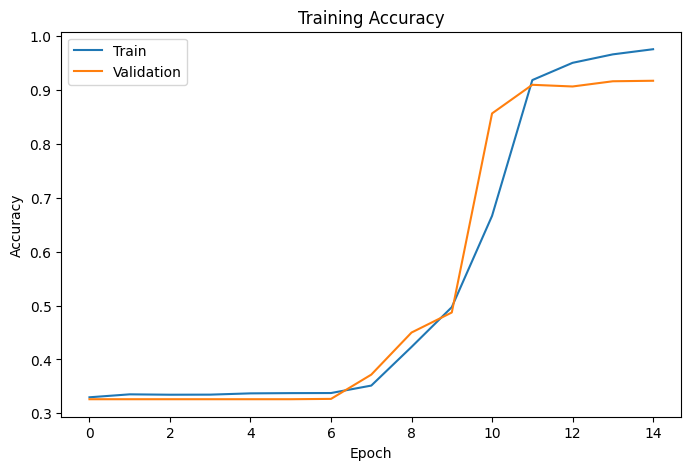

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

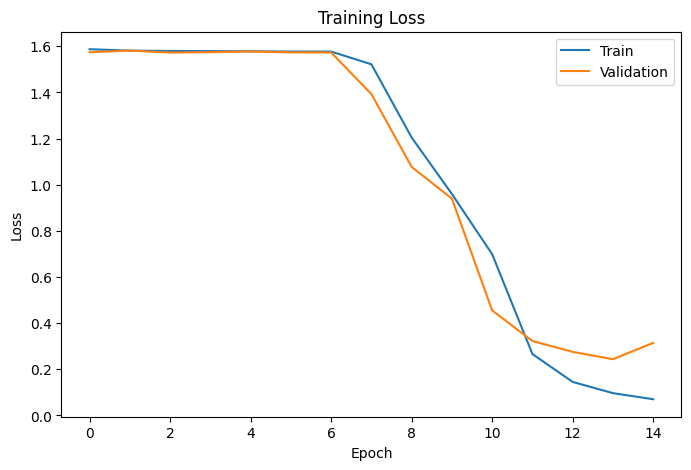

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()


In [32]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9105 - loss: 0.3295
Test Accuracy : 0.9104999899864197


In [33]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)
print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       275
           1       0.85      0.91      0.88       224
           2       0.93      0.94      0.93       695
           3       0.85      0.83      0.84       159
           4       0.95      0.93      0.94       581
           5       0.74      0.64      0.68        66

    accuracy                           0.91      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.91      0.91      0.91      2000



In [41]:
sentence = ["I am very angry with him."]
#sentence = ["I am extremely happy today."]
#sentence = ["I feel scared and nervous."]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

print("Prediction Probabilities:")
print(prediction)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction Probabilities:
[[9.2956257e-01 1.8918511e-02 1.4955680e-03 3.7815431e-04 4.7278356e-02
  2.3668786e-03]]
Predicted Emotion: anger
